## 1.投影法

### 1.1 PCA

#### 1.1.1 主成分矩阵

In [2]:
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target
# 零中心化
X_centered = X-X.mean(axis=0)
# 使用SVD获取主成分
U, s, Vt = np.linalg.svd(X_centered)
# 查看前两个主成分的单位向量
c1 = Vt[0]
c2 = Vt[1]
Vt.shape

(4, 4)

### 1. $X = U \Sigma V^T$ 返回值详解

* **`U` (左奇异向量)**：描述了样本之间的相关性。在 PCA 的视角下，它与投影后的坐标有关。
* **`s` (奇异值)**：这是一个**一维数组**，按从大到小排列。它衡量了每个主成分的重要程度（对应特征值的平方根）。
* **`Vt` (右奇异向量的转置)**：**这就是你之前截图中重点提到的 $V$。** 它的每一行（注意是 `Vt` 的行）就是一个主成分的单位向量（PC 方向）。

### 2. 为什么在 PCA 里用奇异值分解，而不是特征值分解？

1. **数值稳定性**：直接处理原始数据矩阵 $X$ 比先算 $X^T X$（协方差矩阵）更精确。计算 $X^T X$ 会导致数值精度的平方级损失。
2. **通用性**：特征值分解要求矩阵必须是方阵，而 SVD 适用于**任何形状**的矩阵（行数和列数可以不等）。

* **输入必须中心化**：在使用 `svd` 进行 PCA 降维前，一定要先做 `X - X.mean(axis=0)`。否则，SVD 找出的第一方向会指向数据的质心，而不是方差最大的方向。（误认为“原点到数据中心的距离”是一个最重要的“变化方向”。）
* **`Vt` 的形状**：NumPy 返回的是 $V$ 的转置（$V^T$），所以提取第 $k$ 个主成分时是取**行** `Vt[k]`，而不是列。

### 3.几个含义对比
#### 1. 奇异值 vs 特征值：对应关系直接

* **数学联系**：在数据中心化后，$\lambda_i = \frac{\sigma_i^2}{m-1}$。也就是说，**奇异值的平方（经过缩放）就是特征值**。它们都代表了该主成分的重要性（即方差）。

#### 2. 主成分 vs 特征向量：本质是同一个

* **主成分方向**：在 SVD 中对应的是右奇异矩阵V的列( `Vt` 的行)。
* **特征向量**：在协方差矩阵分解中，它指向方差最大的轴。
* **结论**：**右奇异向量（$V$ 的列）就是协方差矩阵的特征向量**。它们共同定义了降维时的投影方向。

#### 3. 左奇异向量：并不是非对角线元素

左奇异向量 $U$ 的含义与协方差矩阵的非对角线元素（协方差）差别较大：

* **协方差矩阵的非对角线元素**：表示不同特征（属性）之间的相关性。
* **左奇异向量 ($U$)**：它描述的是**样本与主成分之间的关系**。
    * 形象地说，如果你把 $X$ 投影到主成分空间，得到的**新坐标**其实就隐藏在 $U \Sigma$ 中。
    * 它反映了每个样本在对应主成分方向上的“贡献度”或“投影强度”。
* 左奇异向量 $U$为标准化坐标，它只保留了样本之间的相对结构，而抹平了不同主成分之间的“威力”差异；$U \Sigma$ 是投影坐标，是样本在降维后的新空间（主成分空间）中的实际位置
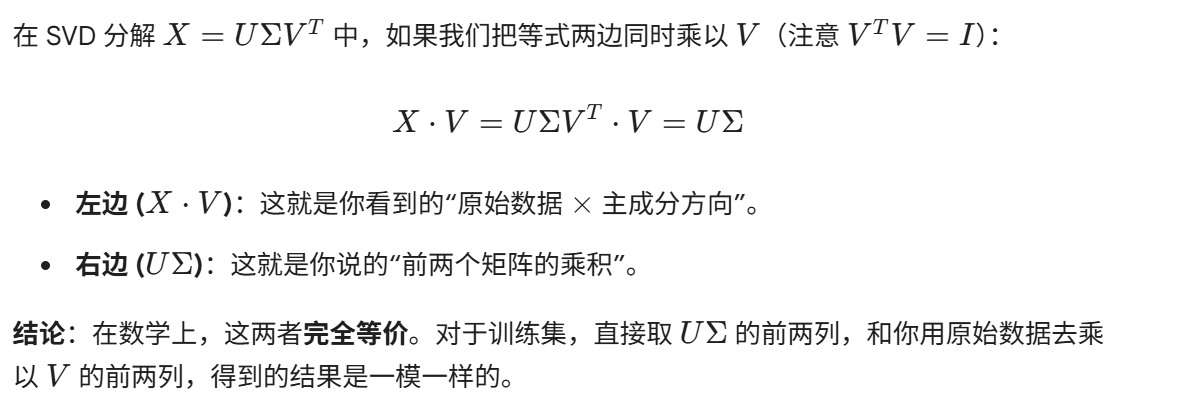

#### 总结对应表

| SVD 概念 | 对应统计学/协方差矩阵概念 | 物理意义 |
| --- | --- | --- |
| **右奇异向量 ($V$)** | **特征向量** | 主成分的方向（坐标轴） |
| **奇异值 ($\sigma$)** | **特征值的平方根** | 该方向上包含的信息量（方差） |
| **左奇异向量 ($U$)** | **投影后的标准化坐标** | 样本在主成分轴上的相对位置 |

* 协方差矩阵的**非对角线元素**如果很大，说明特征冗余，这时候 PCA/SVD 就会通过旋转坐标轴，把这种相关性“吸收”掉，变成相互垂直（独立）的主成分。
* 这种“吸收”过程，本质上就是在寻找**低维子空间**。

### 4. 如果奇异值分解的前两个矩阵已经能得到投影坐标,那为什么还要Vt来反映方差变化最大的方向

> 简单来说：$U\Sigma$ 确实已经给了你**训练集**的投影坐标，但如果你没有 $V^\top$，你就失去了**降维的“规则”**。

#### 1. 它是处理“新数据”的映射器（Mapper）

$U$ 和 $\Sigma$ 只能告诉你**当前这批**训练数据在降维后在哪。但机器学习的目的是处理“新样本”。

* **场景**：你训练好了一个模型，现在来了一个新的测试样本 $x_{new}$。
* **问题**：$U$ 矩阵里没有这个新样本的位置，你无法通过 $U$ 得到它的投影。
* **解决**：你需要主成分方向 $V^\top$。通过计算 $x_{new} \cdot V$，你才能把这个新样本投射到跟训练集一样的低维子空间里。

#### 2. 它是“子空间”的几何定义

$U\Sigma$ 只是几个点，而 $V^\top$ 定义了一个**物理方向**。

* **方差最大的方向**：$V^\top$ 的第一行告诉你在原始的高维空间里，哪条线是数据波动最剧烈的。
* **物理解释**：在多模态研究中，你可能想知道“到底哪些原始特征对这个主成分贡献最大？”。这需要查看 $V^\top$ 里的权重。比如 $V^\top$ 的第一行里，某个图像特征的系数很高，你就能解释：“第一主成分主要由图像的亮度决定”。

#### 1.1.2 向下投影到d维(将数据集投影到前d个主成分确定的超平面上)

In [3]:
W2 = Vt[:2].T # 主成分变成了两列,这两列向量定义了一个二维平面（子空间）的基底。
X2D = X_centered @ W2 # 矩阵乘法：(m,n)x(n,2) = (m,2)

#### 1.1.3 使用sklearn（自动处理数据居中问题）

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2) # 意味着只保留 SVD 分解后最大的前 2 个奇异值对应的特征向量
X2D = pca.fit_transform(X)
#  W 的转置（pca.components_）的形状：(d', d)


'''可解释方差比'''
pca.explained_variance_ratio_

array([0.92461872, 0.05306648])

#### 1.1.4 选择正确的维度

#### 方法1：在不降维的情况下执行PCA，计算保留95%训练集方差所需的最小维度

In [5]:
# 1.数据加载与准备
# fetch_openml 用于从 OpenML 平台下载数据集。
# as_frame=False 确保返回的是NumPy数组而非 Pandas Dataframe（数组更适合后续的数学运算）
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784',as_frame=False) # 每个样本有 784 个特征
X_train,y_train = mnist.data[:60_000],mnist.target[:60_000]
X_test,y_test = mnist.data[60_000:],mnist.target[60_000:]

# 2. 初始化与拟合
pca = PCA() # 不降维情况
pca.fit(X_train) # 计算出了 784 个主成分方向及其对应的方差大小

# 3. 累积可解释方差并寻找目标维度 d
'''假设前三个成分的方差占比是 [0.7, 0.2, 0.05]。cumsum 就会得到 [0.7, 0.9, 0.95]。
它告诉你：如果保留前 k 个维度，总共能保留多少比例的信息。'''
cumsum = np.cumsum(pca.explained_variance_ratio_)
'''cumsum >= 0.95：返回一个布尔数组（如 [False, False, True, True...]）当累计方差第一次超过 95% 时变为 True。
np.argmax()：返回数组中最大值的“第一个索引”。对于布尔数组，它会找到第一个 True 的位置。'''
d = np.argmax(cumsum >= 0.95) + 1 # 加 1是因为索引从0开始

In [6]:
# 实际上,n_components的值既可以指定要保留的维数，还可以设置维要保留的方差率（比如0.95）
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_train)

#### 方法二：绘制可解释方差关于维度的函数，寻找曲线的拐点
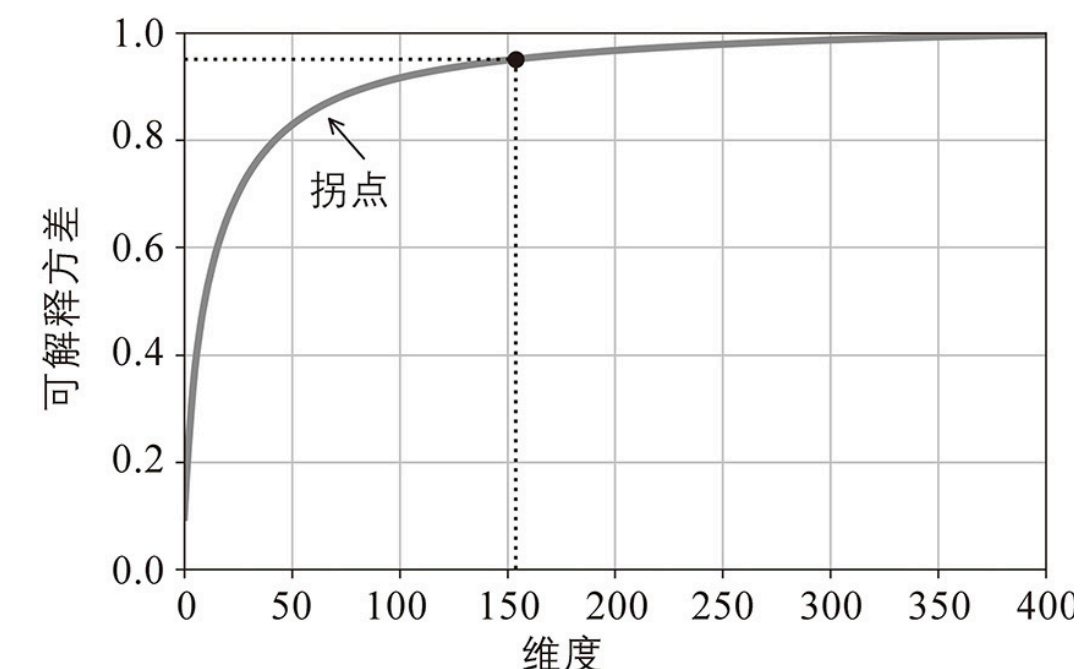

#### 方法三：当我们使用降维作为监督学习任务的预处理，可以使用RandomizedSearchCV为PCA和随机森林分类器找到合适的超参数组合

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
# 随机搜索调参器。它不会尝试所有参数组合（太慢了），而是从指定的范围内随机抽取 $n$ 组进行测试，效率很高。
from sklearn.pipeline import make_pipeline

# 1.构建分类器
clf = make_pipeline(PCA(random_state=42),
                    RandomForestClassifier(random_state=42))
# 2.定义参数搜索空间
param_distrib = {
    "pca__n_components": np.arange(10, 80),
    "randomforestclassifier__n_estimators": np.arange(50, 500)
}
# 3.配置并运行随机搜索
rnd_search = RandomizedSearchCV(clf, param_distrib, n_iter=10, cv=3,
                                random_state=42)
'''n_iter=10：随机挑选 10 组不同的参数组合进行测试。
cv=3：3 折交叉验证。"每一组"参数都会在数据上跑 3 次(每一次的验证集是不同的33%)，取平均分。'''
rnd_search.fit(X_train[:1000], y_train[:1000])
# 4.查看最佳超参数
print(rnd_search.best_params_)
# 补充：pca.inverse_transform 可以将缩减后的数据集解压缩回原来的维度，与原始数据的均方距离称为重构误差

{'randomforestclassifier__n_estimators': np.int64(475), 'pca__n_components': np.int64(57)}


#### 1.1.5 PCA之上的一些优化
### 1. 加快训练速度 => 随机PCA
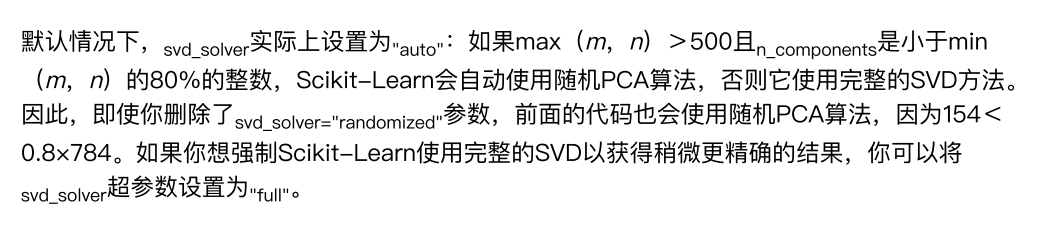

### 2.处理较大数据集：
#### 2.1 增量PCA（将训练集划分为多个小批量）

In [ ]:
from sklearn.decomposition import IncrementalPCA

n_batches = 100
inc_pca = IncrementalPCA(n_components=154)
for X_batch in np.array_split(X_train,n_batches): # 按照索引进行切分
    inc_pca.partial_fit(X_batch) # 它会根据当前批次的数据增量式地更新主成分方向，而不会忘记之前批次学到的信息。
X_reduced = inc_pca.transform(X_train)        

#### 1. 如果需要随机切片怎么办(需要保持每个批量数据分布一致)

如果原始数据有特定的排列规律（比如前 1000 个全是数字 "0"，后 1000 个全是数字 "1"），那么顺序切片会让 `partial_fit` 的学习过程变得非常偏激。

在这种情况下，应该**在切片前进行索引打乱**：

- 生成随机索引: indices = np.random.permutation(len(X_train))
- 根据随机索引重新排列数据: X_shuffled = X_train[indices]
- 然后再进行顺序切片，此时每一块在物理上是连续的，但在逻辑上是随机的

#### 2.`split` vs `array_split`

* **`np.split`**：要求必须能**整除**。如果 $100$ 条数据分 $3$ 组，它会报错。
* **`np.array_split`**：更加鲁棒。如果不能整除，它会自动调整每一块的大小（比如前几块多 1 条数据），保证所有数据都被分配。

#### 2.2 Out-of-Core（外存计算）
不把数据一次性塞进内存，而是留在磁盘上。

In [ ]:
# --- 第一步：安全地创建 memmap (填坑) ---
filename = "my_mnist.mmap"
total_samples = 60000  # 假设总行数
n_features = 784       # 28x28 像素

# 在硬盘上划定地盘，此时内存几乎不被占用
X_mmap = np.memmap(filename, dtype='float32', mode='w+', shape=(total_samples, n_features))

# 模拟分块处理过程（比如从原始大文件读取）
batch_size = 5000 
for i in range(0, total_samples, batch_size):
    # 每次只加载一小块数据到内存中
    # 这里的 load_raw_data 是一个示意函数，表示你从磁盘其他地方读取一小块
    chunk = load_raw_data(start_index=i, size=batch_size) 
    
    # 把内存里 chunk 变量的数据，“搬”到了操作系统管辖的 页面缓存（Page Cache） 中
    X_mmap[i : i + batch_size] = chunk 
    
    # 这一步最关键：强制刷入磁盘，确保这批数据不在内存缓存中堆积
    X_mmap.flush()

# --- 第二步：使用 IncrementalPCA 处理 ---
# 此时 X_mmap 已经在磁盘上了，我们可以重新以只读模式载入
X_mmap_read = np.memmap(filename, dtype='float32', mode='readonly', shape=(total_samples, n_features))

inc_pca = IncrementalPCA(n_components=154, batch_size=batch_size)
# 这里的 .fit 会自动识别 memmap，每次只读取 batch_size 大小的数据到内存计算
inc_pca.fit(X_mmap_read)

`np.memmap` 的存在是为了解决一个矛盾：**“数据太大，内存太小”**。

### 1. 直观理解：虚拟内存

通常我们处理数据的流程是：

1. **读取**：从硬盘读取整个文件。
2. **加载**：全部塞进内存（RAM）。
3. **计算**：CPU 访问内存进行计算。

而 `np.memmap` 绕过了“全部加载”这一步：
> 存储原数据的文件处于磁盘中，而memmap建立了一个磁盘文件与数组的映射关系。当你访问 `X[100:200]` 时，它才**实时**从硬盘里把这 100 行数据抓取到内存缓存里；一旦用完了，这块内存就可以被释放，去加载下一块。

#### 完整流程：

> 先在内存申请一个指定形状的 memmap 对象作为接口，它本身不存储真实数据而仅包含该硬盘二进制文件的描述信息。随后利用该接口作为通道，分批将内存中解压后的数字矩阵推送到系统缓存，并通过强制刷入（flush）使其持久化为硬盘中的二进制数据。此后只需将该数组作为“虚拟内存”接口，便能像操作普通内存数组一样，利用操作系统的缓存机制对硬盘中海量的解压后数字矩阵进行高效处理。

### 2. 有什么优势

1. **突破物理内存限制**：
如果你只有 8GB 内存，但要处理一个 50GB 的视频数据集或大型传感器日志，普通方式会直接报错 `MemoryError`。用 `memmap`，你可以像操作普通数组一样操作这 50GB 数据。
2. **极速启动**：
传统的 `np.load()` 加载大文件需要等很久。而 `np.memmap` 的“打开”动作几乎是瞬间的，因为它只是建立了一个“映射关系”，并没有真正读入数据。
3. **数据持久化**：
你在 `memmap` 数组上做的任何修改（如果设置了 `mode='r+'`），只要调用 `flush()`，就会直接同步到硬盘的文件里。这对于处理需要频繁保存的中间结果非常方便。

### 3. 数据存储的误区

#### 3.1 第一阶段：下载的数据集（在磁盘里，是“压缩态”）

我们从网上下载的 MNIST 或多模态视频包，它们以 `.jpg`、`.mp4` 或 `.zip` 的形式躺在你的**硬盘**里。

* **特点**：体积小（压缩过），但计算机**看不懂**。计算机的 CPU/GPU 无法直接对一个 `.jpg` 文件进行加减乘除。

#### 3.2 第二阶段：读取与解压（在内存里，变成“数字矩阵”）

当我们运行代码（比如 `cv2.imread` 或 `pd.read_csv`）时：

1. 计算机把这个压缩文件从硬盘抓到**内存**。
2. CPU 进行“解压缩”计算。
3. **关键点**：解压后的数据变成了**原始的数字矩阵（NumPy Array）**。

**这就是问题所在：**

* 一个 $1\text{MB}$ 的 JPG 图片，解压成像素矩阵后，在内存里可能会膨胀到 $10\text{MB}$ 甚至更多。
* **内存爆炸点**：如果你有 $100\text{GB}$ 的图片，虽然硬盘（$1\text{TB}$）存得下，但当你尝试把它们全部“解压并读入内存”准备训练时，内存（通常只有 $16\text{GB}$ 或 $32\text{GB}$）瞬间就撑爆了。

### 1.2 随机投影
这听起来可能非常疯狂，但是相似(非常不同)的实例投影后依旧保持相似(非常不同)

#### 1.2.1 手动实现

In [11]:
from sklearn.random_projection import johnson_lindenstrauss_min_dim

# 1. 计算理论最小目标维度 d
m, eps = 5_000, 0.1  # 5000个样本，允许10%的距离误差
d = johnson_lindenstrauss_min_dim(m, eps=eps)
# 输出 d 约为 7300

# 2. 构建随机投影矩阵 P
n = 20_000  # 原始特征维度
np.random.seed(42)
# 生成服从高斯分布的随机矩阵，并进行标准差缩放（1/sqrt(d)）
P = np.random.randn(d, n) / np.sqrt(d)

# 3. 模拟数据集并执行降维（矩阵乘法）
X = np.random.randn(m, n)  # 生成一个虚假的高维数据集
X_reduced = X @ P.T        # 降维后的矩阵 = 原始数据 乘以 投影矩阵的转置

#### 1. 核心理论：Johnson-Lindenstrauss (JL) 引理

一个关键问题：**降维多少才合适？**

为了保证降维后点与点之间的距离变化不超过一个公差 $\epsilon$，JL 引理给出了最小目标维度 $d$ 的计算公式：

$$d \ge \frac{4 \ln(m)}{\epsilon^2/2 - \epsilon^3/3}$$

* **$m$**：样本数量（实例数）。
* **$\epsilon$**：允许的距离扭曲程度（如 0.1 代表 10% 的误差）。
* **惊人的结论**：公式中完全没有出现原始特征维度 $n$。这意味着，无论你原始数据是 1 万维还是 100 万维，只要样本数 $m$ 固定，降维到的目标维度 $d$ 是一样的。

#### 2. 关键结论

* **无需训练**：传统的 PCA 需要根据数据分布去计算主成分，但随机投影**根本不看数据本身**。
* **算法独立性**：生成随机矩阵 $P$ 只需要知道数据集的形状（样本数和原始维度），而不需要查看数据内容。
* **高效性**：它非常适合处理动态更新的数据集，或者维度高到连 PCA 都算不动的场景。

#### 总结
如果你不需要像 PCA 那样精准地保留方差，而只是想**快速**降维并**保住点与点之间的相似性**（比如做近邻搜索），随机投影是一个性价比极高的数学“捷径”。它通过牺牲一点点精度（由 $\epsilon$ 控制），换取了巨大的计算效率。

#### 1.2.2 调用sklearn中的类

### 1. 高斯随机投影

In [13]:

from sklearn.random_projection import GaussianRandomProjection

# 使用 eps 自动调用JL确定维度并降维
# 在调用 .fit() 时，它会生成并存储一个随机矩阵在 components_ 属性中；
# 调用 .transform() 时，直接用这个矩阵执行投影。
gaussian_rnd_proj = GaussianRandomProjection(eps=0.1, random_state=42)
X_reduced = gaussian_rnd_proj.fit_transform(X)

###  2. 稀疏随机投影--更优的选择

在处理大型数据集具有巨大优势：

* **核心区别**：它生成的随机投影矩阵是**稀疏的**（大部分元素为 0）。
* **性能飞跃**：
    * **内存**：示例中内存占用从 1.2GB 骤降至 **25MB**。
    * **速度**：降维速度提升了约 **50%**。

* **密度 ($r$)**：非零项的比率称为密度。默认情况下，如果特征数 $n=20000$，大约每 141 个单元中只有一个是非零项。
* **非零项取值**：非零值要么是 $-v$，要么是 $+v$（概率相等），其中：

$$v = 1/\sqrt{dr} \quad \text{或} \quad 1/\sqrt{n}$$

### 3. 数据恢复：逆变换（Inverse Transform）

随机投影通常是不可逆的，我们可利用伪逆矩阵（Pseudo-inverse）进行“近似恢复”：

In [ ]:
# 逆变换：尝试从降维数据恢复原始维度
# 1. 计算投影矩阵的伪逆
components_pinv = np.linalg.pinv(gaussian_rnd_proj.components_)
# 2. 矩阵乘法还原
X_recovered = X_reduced @ components_pinv.T

* **计算伪逆**：使用 `np.linalg.pinv()` 计算投影矩阵的伪逆。
* **恢复公式**：

$$X_{recovered} = X_{reduced} \cdot (components\_pinv)^T$$

* **原理**：虽然降维过程丢失了信息，但通过伪逆变换，可以将数据映射回原始高维空间。虽然恢复后的数据与原数据不完全相同，但它能在最大程度上保持原始的结构。

对于大型或稀疏数据集，**通常最好使用 `SparseRandomProjection` 而不是第一个转换器**，因为它在保持距离特性不变的前提下，极大地节省了计算资源和内存。

## 2.流形学习

### 2.1 局部线性嵌入(LLE)